<a target="_blank" href="https://colab.research.google.com/github/ZHAW-ZAV/TSO-FS26-students/blob/main/02_python_viz/02_01_intro_plotly.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [4]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

file_id_co2 = "1-FxcOXUXMrXZzDzeLgarKoQfa2QN_sXO"
file_id_trajs = "1CRNprh5oSxZntkmEJbCMTN3Htf5cPb4u"

if IN_COLAB:
    path_to_co2 = "/content/data/co2_emmissions_by_state.csv"
    os.makedirs(os.path.dirname(path_to_co2), exist_ok=True)
    !gdown "https://drive.google.com/uc?id={file_id_co2}" -O "{path_to_co2}"

    path_to_trajs = "/content/data/plotly_trajs.csv"
    os.makedirs(os.path.dirname(path_to_trajs), exist_ok=True)
    !gdown "https://drive.google.com/uc?id={file_id_trajs}" -O "{path_to_trajs}"

    # Unfortunately, Colab does not come with the Kaleido library installed.
    !pip install -q "kaleido==0.2.1"
else:
    import gdown

    url = f"https://drive.google.com/uc?id={file_id_co2}"
    path_to_co2 = "data/co2_emmissions_by_state.csv"
    os.makedirs(os.path.dirname(path_to_co2), exist_ok=True)
    gdown.download(url, path_to_co2, quiet=False)

    url = f"https://drive.google.com/uc?id={file_id_trajs}"
    path_to_trajs = "data/plotly_trajs.csv"
    os.makedirs(os.path.dirname(path_to_trajs), exist_ok=True)
    gdown.download(url, path_to_trajs, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1-FxcOXUXMrXZzDzeLgarKoQfa2QN_sXO
To: /Users/wate/Documents/GitHub/TSO-FS26-students/02_python_viz/data/co2_emmissions_by_state.csv
100%|██████████| 241k/241k [00:00<00:00, 8.17MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CRNprh5oSxZntkmEJbCMTN3Htf5cPb4u
To: /Users/wate/Documents/GitHub/TSO-FS26-students/02_python_viz/data/plotly_trajs.csv
100%|██████████| 2.74M/2.74M [00:00<00:00, 32.9MB/s]


The code above loads the data, don't modify.

---------------

***Notebook starts here***

In [5]:
from plotly import graph_objects as go
from plotly import express as px
import pandas as pd

## First steps with Plotly, scatter plots

In [6]:
# We will use the iris dataset for this example
df = px.data.iris()
df

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


In [7]:
# px: scatter plot
# x-axis: sepal_width
# y-axis: sepal_length
# color: petal_length
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="petal_length")
fig.show()

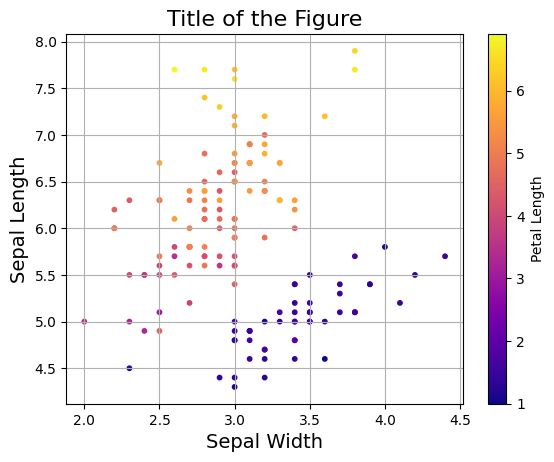

In [8]:
# Just for illustrative purposes, the same figure can be created with matplotlib

import matplotlib.pyplot as plt

sc = plt.scatter(
    df.sepal_width,
    df.sepal_length,
    s=10,
    c=df.petal_length,
    cmap="plasma"
)

plt.colorbar(sc, label="Petal Length")
plt.title('Title of the Figure', fontsize=16)
plt.xlabel("Sepal Width", fontsize=14)
plt.ylabel("Sepal Length", fontsize=14)
plt.grid()
plt.show()

In [ ]:
df = px.data.iris()
fig = go.Figure()

# go: same as before, but this time with go
# x-axis: sepal_width
# y-axis: sepal_length
# color: petal_length
fig.add_trace(
    go.Scatter(
        x=df["sepal_width"],
        y=df["sepal_length"],
        marker_color=df["petal_length"],
        mode="markers",
        marker=dict(showscale=True),
    )
)
fig.show()


In [ ]:
# let's make this plot a bit more interesting:
# - add title
# - add axis labels
# - remove grid lines
# - change the size of the plot
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df["sepal_width"],
        y=df["sepal_length"],
        marker_color=df["petal_length"],
        mode="markers",
        marker=dict(showscale=True, colorbar=dict(title="Petal Length")),
    )
)

fig.update_layout(
    height=500,
    width=700,
    title="Iris dataset",
    xaxis_title="Sepal Width",
    yaxis_title="Sepal Length",
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False),
)
fig.show()

In [ ]:
# px: what happens if we have the color with a categorical variable?
# x-axis: sepal_width
# y-axis: sepal_length
# color: species
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species")
fig.show()

In [ ]:
# go: same as before, but this time with go
# x-axis: sepal_width
# y-axis: sepal_length
# color: species

fig = go.Figure()
species = df["species"].unique()
for s in species:
    df_to_plot = df.query("species == @s")
    fig.add_trace(
        go.Scatter(
            x=df_to_plot["sepal_width"],
            y=df_to_plot["sepal_length"],
            mode="markers",
            name=s,
        )
    )

fig.update_layout(
    title="Iris dataset",
    xaxis_title="Sepal Width",
    yaxis_title="Sepal Length",
    legend=dict(title="Species"),
)
fig.show()

## Some more plots with the CO2 data

In [ ]:
df = pd.read_csv(path_to_co2)
df

In [ ]:
# since we have too many states, let's filter the data to only keep 4 states
to_keep = ["SWITZERLAND", "GERMANY", "ITALY", "FRANCE"]

df = df.query("STATE_NAME in @to_keep")

In [ ]:
# we want to plot the CO2 emissions by year and state
# for that, we need to sum the CO2 emissions by year and state first
df = df.groupby(["YEAR", "STATE_NAME"])["CO2_QTY_TONNES"].sum().reset_index()
df

In [ ]:
# px: let's do a bar plot of the CO2 emissions by year and state
# x-axis: year
# y-axis: CO2 emissions
# color: state
# the bars can be either grouped (barmode='group') or stacked (barmode='stack')
fig = px.bar(df, x="YEAR", y="CO2_QTY_TONNES", color="STATE_NAME", barmode="stack")
fig.show()

In [ ]:
# go: same as before, but this time with go
# x-axis: year
# y-axis: CO2 emissions
# color: state
# the bars can be either grouped (barmode='group') or stacked (barmode='stack')

# unfortunately, we need to loop over the states to add the traces
# this is because go.Bar does not support the color argument
# so we need to create one trace per state
fig = go.Figure()
states = df["STATE_NAME"].unique()
for s in states:
    df_to_plot = df.query("STATE_NAME == @s")
    fig.add_trace(go.Bar(x=df_to_plot["YEAR"], y=df_to_plot["CO2_QTY_TONNES"], name=s))
fig.update_layout(
    title="CO2 emissions by state",
    xaxis_title="Year",
    yaxis_title="CO2 emissions (tonnes)",
    legend=dict(title="State"),
    barmode="stack",
)
fig.show()

In [ ]:
# let's have a look at a flight trajectory
df = pd.read_csv(path_to_trajs).query("flight_id == 'EDW24_20180111'")
df

In [ ]:
# px: let's plot the trajectory on a map
# x-axis: longitude
# y-axis: latitude
# color: altitude
# the map center and zoom can be set with the map argument and
# taking the mean lat/lon can work well. Here a zoom of 4.5 seems
# reasonable (try and error).
fig = px.scatter_map(df, lat="latitude", lon="longitude", color="altitude")
fig.update_layout(
    height=600,
    width=800,
    map=dict(
        center=dict(lat=df["latitude"].mean(), lon=df["longitude"].mean()), zoom=4.5
    ),
)
fig.show()

In [ ]:
# go: same as before, but this time with go
# x-axis: longitude
# y-axis: latitude
# color: altitude
fig = go.Figure()
fig.add_trace(
    go.Scattermap(
        lat=df["latitude"],
        lon=df["longitude"],
        marker=dict(size=10, color=df["altitude"], showscale=True),
    )
)
fig.update_layout(
    height=600,
    width=800,
    map=dict(
        center=dict(lat=df["latitude"].mean(), lon=df["longitude"].mean()), zoom=4.5
    ),
)
fig.show()

## Subplots

In [ ]:
# let's try some subplots
# first, import make_subplots
from plotly.subplots import make_subplots

# make a subplot with 2 rows and 1 column
fig = make_subplots(rows=2, cols=1)

# subplots work only with go, so we need to add the traces with go
# the first row will contain the altitude
# x-axis: timestamp
# y-axis: altitude
fig.add_trace(
    go.Scatter(
        x=df["timestamp"], y=df["altitude"], mode="lines+markers", name="baro altitude"
    ),
    row=1,
    col=1,
)

# the second row will contain the groundspeed
# x-axis: timestamp
# y-axis: groundspeed
fig.add_trace(
    go.Scatter(
        x=df["timestamp"], y=df["groundspeed"], mode="lines+markers", name="groundspeed"
    ),
    row=2,
    col=1,
)
# update the layout:
# - set the height and width
# - add a title
# - add axis labels
fig.update_layout(height=600, width=800, title_text="Flight trajectory")
fig.update_xaxes(title_text="Timestamp", row=1, col=1)
fig.update_xaxes(title_text="Timestamp", row=2, col=1)
fig.update_yaxes(title_text="Altitude", row=1, col=1)
fig.update_yaxes(title_text="Groundspeed", row=2, col=1)
fig.show()

## Export

In [ ]:
# to save the plot, we can use the write_image method
# this will save the plot in the format specified by the extension
fig.write_image("my_image.png")
fig.write_image("my_image.pdf")
fig.write_html("my_image.html")